# Data Exploration & Quality Checks

Generates synthetic **bank transaction training data** (categorization, fraud detection, spending insights, customer Q&A), validates it against the schema, and visualizes instruction/output length distributions before fine-tuning.

## Step 1: Generate Sample Data

Creates a synthetic bank transaction instruction dataset (1000 unique examples covering transaction categorization, fraud analysis, spending insights, and customer support Q&A) and splits it into train/eval/test.

In [ ]:
import sys
from pathlib import Path

RUNEBOOK_ROOT = Path.cwd()  # notebook 01's clone cell already chdir'd here
if str(RUNEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(RUNEBOOK_ROOT))

from scripts.prepare_data import create_sample_data, split_data, validate_and_report

raw_path = RUNEBOOK_ROOT / "data/RAW/training_data.jsonl"
if not raw_path.exists():
    create_sample_data(raw_path, num_samples=1000)
else:
    print(f"Using existing raw data: {raw_path}")

splits = split_data(raw_path)
print("\nData split into train/eval/test")

## Step 2: Validate Splits Against Schema

In [ ]:
from src.data_loader import DataLoader

for split_name in ["train", "eval", "test"]:
    path = RUNEBOOK_ROOT / f"data/curated/{split_name}.jsonl"
    stats = DataLoader.validate_dataset(path)
    print(f"\n{split_name.upper()} ({path}):")
    for key, value in stats.items():
        print(f"  {key}: {value}")


TRAIN (/content/workshop-databricks-ollama-finetuning/data/curated/train.jsonl):
  total_examples: 800
  avg_instruction_length: 80.24875
  max_instruction_length: 100
  avg_output_length: 312.89125
  max_output_length: 610

EVAL (/content/workshop-databricks-ollama-finetuning/data/curated/eval.jsonl):
  total_examples: 100
  avg_instruction_length: 79.19
  max_instruction_length: 100
  avg_output_length: 304.95
  max_output_length: 610

TEST (/content/workshop-databricks-ollama-finetuning/data/curated/test.jsonl):
  total_examples: 100
  avg_instruction_length: 80.35
  max_instruction_length: 108
  avg_output_length: 322.51
  max_output_length: 564


## Step 3: Inspect Example Prompts

Show how a few examples are formatted as chat messages for fine-tuning.

In [ ]:
train_examples = DataLoader.load_dataset(RUNEBOOK_ROOT / "data/curated/train.jsonl")

for example in train_examples[:3]:
    print("--- Chat messages ---")
    for msg in example.to_chat_messages():
        print(f"  [{msg['role']}] {msg['content']}")
    print()

--- Chat messages ---
  [user] Categorize the following bank transaction based on its description.
PARQUEADERO CENTRO - $15,000 COP - 2024-10-02 07:44
  [assistant] Category: Transportation. This is a transportation or mobility expense. Amount of $15,000 COP charged on 2024-10-02 07:44.

--- Chat messages ---
  [user] Based on the customer's transaction history, suggest a personalized savings plan.
Profile: Income $5,601,076 COP/month, expenses average $4,877,683 COP. Current savings: $0 COP. Recurring discretionary: nightlife (3x/month), online shopping. Goal: investment portfolio $8,422,567 COP (long-term wealth building).
  [assistant] Current surplus: $723,393 COP/month (11.6 months to goal at current rate). Optimizations: reduce top 2 discretionary categories by 40% to free up ~$434,035 COP/month. New capacity: $1,157,428 COP/month. Revised timeline: 7.3 months. Set up automatic $1,157,428 COP transfer on payday to a dedicated savings pocket.

--- Chat messages ---
  [user] Catego

## Step 4: Length Distributions

Plot instruction and output length histograms across the training set.

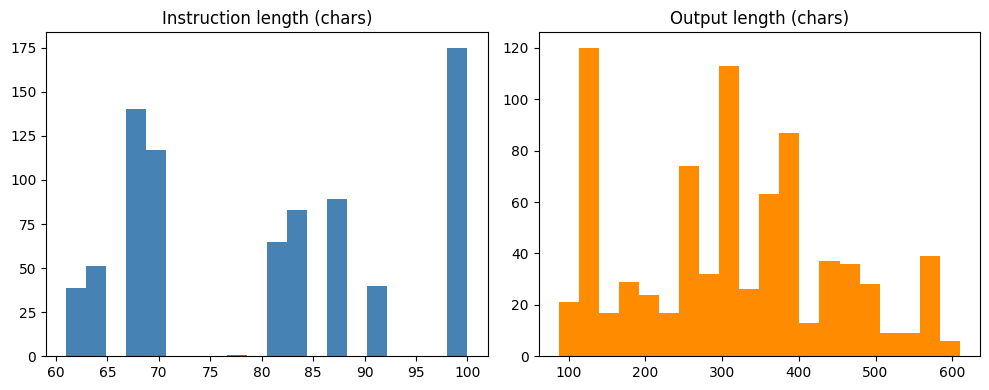

In [ ]:
import matplotlib.pyplot as plt

instruction_lengths = [len(ex.instruction) for ex in train_examples]
output_lengths = [len(ex.output) for ex in train_examples]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(instruction_lengths, bins=20, color="steelblue")
axes[0].set_title("Instruction length (chars)")
axes[1].hist(output_lengths, bins=20, color="darkorange")
axes[1].set_title("Output length (chars)")
plt.tight_layout()
plt.show()

## Step 5: Task Type Distribution

Bucket examples by their instruction text as a rough proxy for task type.

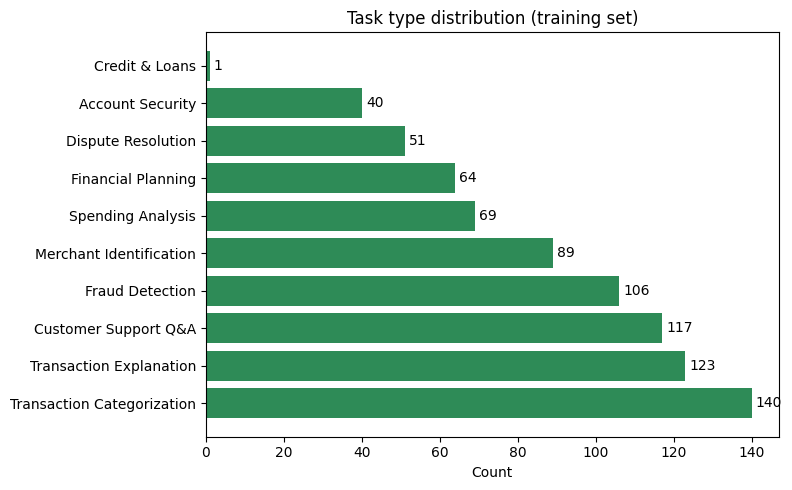

In [ ]:
from collections import Counter

def classify_task(instruction: str) -> str:
    i = instruction.lower()
    if "categorize" in i:
        return "Transaction Categorization"
    elif "fraud" in i:
        return "Fraud Detection"
    elif "spending insight" in i or "monthly transaction summary" in i:
        return "Spending Analysis"
    elif "customer question" in i:
        return "Customer Support Q&A"
    elif "pending transaction" in i or "explain" in i:
        return "Transaction Explanation"
    elif "dispute" in i or "disputing" in i:
        return "Dispute Resolution"
    elif "merchant" in i or "recognize" in i:
        return "Merchant Identification"
    elif "savings" in i or "budget" in i or "financial" in i:
        return "Financial Planning"
    elif "declined" in i or "payment" in i:
        return "Payment Failures"
    elif "security" in i:
        return "Account Security"
    elif "credit" in i:
        return "Credit & Loans"
    elif "tax" in i:
        return "Tax Analysis"
    elif "international" in i or "fees" in i:
        return "International Transactions"
    else:
        return "Other"

task_counts = Counter(classify_task(ex.instruction) for ex in train_examples)
task_counts = dict(task_counts.most_common())

plt.figure(figsize=(8, 5))
bars = plt.barh(list(task_counts.keys()), list(task_counts.values()), color="seagreen")
plt.xlabel("Count")
plt.title("Task type distribution (training set)")
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

## Data Exploration Complete

Data is validated and ready for fine-tuning. Next: run `03_finetuning.ipynb`.